### 학습목표
- 다양한 활성화함수와 경사하강법 조합을 활용하여 모델의 성능을 비교해보자~
- 손글씨 데이터 사용
- 어떤 조합이 좋은 성능을 보이는지 확인하고 활용할 수 있다.

### 조합(활성화함수, 경사하강법)
- model1
  - sigmoid + SGD
- model2
  - relu + SGD
- model3
  - relu + Adam

##### 실습내용
- 모델 설계, 학습, 시각화
  - 모델 학습 후 하나의 그래프에 1,2,3 결과를 출력
- 모델 설계가이드
  - 중간층 5개층 (64,128,256,128,64)
  - 학습횟수 20번, 검증데이터 20% 사용, 배치사이즈 64

In [1]:
# 라이브러리 불러오기 (기본라이브러리, 모델링 라이브러리)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
# 손글씨데이터불러오기
(X_train,y_train),(X_test,y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [2]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input,Dense, Flatten
from tensorflow.keras.optimizers import SGD, Adam # 최적화함수

In [10]:
# 1.sigmoid + SGD
model1 = Sequential()
model1.add(Input(shape = (28,28)))
model1.add(Flatten())
model1.add(Dense(units = 64, activation='sigmoid'))
model1.add(Dense(units = 128, activation='sigmoid'))
model1.add(Dense(units = 256, activation='sigmoid'))
model1.add(Dense(units = 128, activation='sigmoid'))
model1.add(Dense(units = 64, activation='sigmoid'))
model1.add(Dense(units = 10, activation='softmax'))
# 학습방법 및 평가방법 설정
model1.compile(loss = 'sparse_categorical_crossentropy',
               optimizer = 'SGD',
               metrics = ['accuracy'])
# 학습
model1.fit(X_train, y_train, validation_split = 0.2, epochs = 20, batch_size = 64)

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.1117 - loss: 2.3089 - val_accuracy: 0.1060 - val_loss: 2.3022
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.1136 - loss: 2.3017 - val_accuracy: 0.1060 - val_loss: 2.3026
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.1132 - loss: 2.3012 - val_accuracy: 0.1060 - val_loss: 2.3020
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.1139 - loss: 2.3009 - val_accuracy: 0.1060 - val_loss: 2.3019
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.1140 - loss: 2.3007 - val_accuracy: 0.1060 - val_loss: 2.3009
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.1157 - loss: 2.3004 - val_accuracy: 0.1060 - val_loss: 2.3014
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.1151 - loss: 2.3003 - val_accuracy: 0.1060 - val_loss: 2.3007
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.1150 - loss: 2.2999 - val_accuracy: 0.

In [6]:
# 2. relu + SGD
model2 = Sequential()
model2.add(Input(shape = (28,28)))
model2.add(Flatten())
model2.add(Dense(units = 64, activation='relu'))
model2.add(Dense(units = 128, activation='relu'))
model2.add(Dense(units = 256, activation='relu'))
model2.add(Dense(units = 128, activation='relu'))
model2.add(Dense(units = 64, activation='relu'))
model2.add(Dense(units = 10, activation='softmax'))
# 학습방법 및 평가방법 설정
model2.compile(loss = 'sparse_categorical_crossentropy',
               optimizer = SGD(learning_rate= 0.001), # SGD 기본학습률: 0.01
               metrics = ['accuracy'])
# 학습
model2.fit(X_train, y_train, validation_split = 0.2, epochs = 20, batch_size = 64)

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7341 - loss: 1.0633 - val_accuracy: 0.8495 - val_loss: 0.4979
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8728 - loss: 0.4202 - val_accuracy: 0.8922 - val_loss: 0.3504
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9032 - loss: 0.3231 - val_accuracy: 0.9072 - val_loss: 0.3058
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9194 - loss: 0.2715 - val_accuracy: 0.9127 - val_loss: 0.2907
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9295 - loss: 0.2360 - val_accuracy: 0.9218 - val_loss: 0.2555
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9359 - loss: 0.2110 - val_accuracy: 0.9261 - val_loss: 0.2404
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9424 - loss: 0.1903 - val_accuracy: 0.9268 - val_loss: 0.2415
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9474 - loss: 0.1748 - val_accuracy: 0.

In [7]:
# 3. relu + adam
model3 = Sequential()
model3.add(Input(shape = (28,28)))
model3.add(Flatten())
model3.add(Dense(units = 64, activation='relu'))
model3.add(Dense(units = 128, activation='relu'))
model3.add(Dense(units = 256, activation='relu'))
model3.add(Dense(units = 128, activation='relu'))
model3.add(Dense(units = 64, activation='relu'))
model3.add(Dense(units = 10, activation='softmax'))
# 학습방법 및 평가방법 설정
model3.compile(loss = 'sparse_categorical_crossentropy',
               optimizer = Adam(),  # adam 기본학습률 0.001
               metrics = ['accuracy'])
# 학습
model3.fit(X_train, y_train, validation_split = 0.2, epochs = 20, batch_size = 64)

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8581 - loss: 0.5903 - val_accuracy: 0.9239 - val_loss: 0.2597
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9417 - loss: 0.2010 - val_accuracy: 0.9290 - val_loss: 0.2828
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9547 - loss: 0.1537 - val_accuracy: 0.9569 - val_loss: 0.1500
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9617 - loss: 0.1267 - val_accuracy: 0.9601 - val_loss: 0.1424
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9673 - loss: 0.1111 - val_accuracy: 0.9554 - val_loss: 0.1722
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9710 - loss: 0.0989 - val_accuracy: 0.9597 - val_loss: 0.1563
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9726 - loss: 0.0918 - val_accuracy: 0.9592 - val_loss: 0.1702
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9760 - loss: 0.0826 - val_accuracy: 0.

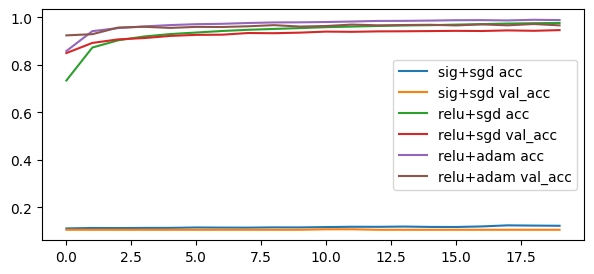

In [11]:
plt.figure(figsize = (7,3))
plt.plot(model1.history.history['accuracy'], label = 'sig+sgd acc')
plt.plot(model1.history.history['val_accuracy'], label = 'sig+sgd val_acc')
plt.plot(model2.history.history['accuracy'], label = 'relu+sgd acc')
plt.plot(model2.history.history['val_accuracy'], label = 'relu+sgd val_acc')
plt.plot(model3.history.history['accuracy'], label = 'relu+adam acc')
plt.plot(model3.history.history['val_accuracy'], label = 'relu+adam val_acc')
plt.legend()
plt.show()

### callback 함수
- 모델 저장(modelcheckpoint)
  - 딥러닝 학습시 지정된 epochs 가 모두 진행될 경우 과대적합일 경우 있음 -> 중간중간에 일반화된 모델을 저장
  - 커널이 끊기면 정보가 날아가기 때문에 학습내용을 저장
- 모델 조기학습중단 (earlystopping)
  - epochs 를 크게 설정했을시 일정 횟수 이후로는 모델의 성능개선이 되지않는 경우가 있음 -> 시간낭비, 자원낭비
  - 모델의 성능이 더이상 개선되지 않을 때 조기 중단

In [12]:
# 드라이브 연결
%cd /content/drive/MyDrive/Colab Notebooks/2. 수업/26.02 LG전자DX스쿨(5기)/3. 딥러닝

/content/drive/MyDrive/Colab Notebooks/2. 수업/26.02 LG전자DX스쿨(5기)/3. 딥러닝


In [13]:
!pwd

/content/drive/MyDrive/Colab Notebooks/2. 수업/26.02 LG전자DX스쿨(5기)/3. 딥러닝


In [14]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [19]:
# 모델 저장
# 경로 설정
model_path = './data/model/model_{epoch:02d}_{val_accuracy:0.3f}.keras'
mc = ModelCheckpoint(filepath=model_path, # 모델저장 경로 설정
                     verbose = 1, # 진행과정 로그출력, 0 -> 미출력, 1 -> 출력
                      save_best_only = True, # 모델이 최고성능을 갱신할때만 저장
                     monitor = 'val_accuracy' ) # 모델의 성능확인 기준 지표

In [20]:
# 조기학습 중단
es = EarlyStopping(monitor='val_accuracy',
                   verbose = 1,
                   patience = 10) # 모델의 성능개선을 기다려주는 횟수

In [24]:
# 1.sigmoid + SGD
model1 = Sequential()
model1.add(Input(shape = (28,28)))
model1.add(Flatten())
model1.add(Dense(units = 64, activation='sigmoid'))
model1.add(Dense(units = 128, activation='sigmoid'))
model1.add(Dense(units = 256, activation='sigmoid'))
model1.add(Dense(units = 128, activation='sigmoid'))
model1.add(Dense(units = 64, activation='relu'))
model1.add(Dense(units = 10, activation='softmax'))
# 학습방법 및 평가방법 설정
model1.compile(loss = 'sparse_categorical_crossentropy',
               optimizer = 'SGD',
               metrics = ['accuracy'])
# 학습
model1.fit(X_train, y_train, validation_split = 0.2, epochs = 100, batch_size = 64,
           callbacks = [mc,es])

Epoch 1/100
740/750 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1111 - loss: 2.3115
Epoch 1: val_accuracy did not improve from 0.11800
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.1139 - loss: 2.3033 - val_accuracy: 0.1060 - val_loss: 2.3011
Epoch 2/100
746/750 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1194 - loss: 2.2993
Epoch 2: val_accuracy improved from 0.11800 to 0.18467, saving model to ./data/model/model_02_0.185.keras

Epoch 2: finished saving model to ./data/model/model_02_0.185.keras
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.1171 - loss: 2.2991 - val_accuracy: 0.1847 - val_loss: 2.3004
Epoch 3/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1254 - loss: 2.2979
Epoch 3: val_accuracy did not improve from 0.18467
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.1217 - loss: 2.2973 - val_accuracy: 0.1060 - val_loss: 2.2966
Epoch 4/100
739/750 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1230 - loss: 2.2958
Epoch 4: val_accuracy di

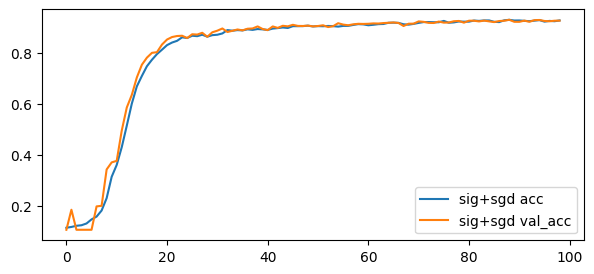

In [25]:
plt.figure(figsize = (7,3))
plt.plot(model1.history.history['accuracy'], label = 'sig+sgd acc')
plt.plot(model1.history.history['val_accuracy'], label = 'sig+sgd val_acc')
plt.legend()
plt.show()

### 직접 쓴 손글씨 활용하여 모델 평가
- best 모델 불러와서 직접 작성한 손글씨 데이터 평가

In [26]:
# best 모델 불러오기
from tensorflow.keras.models import load_model
best_model = load_model('./data/model/model_89_0.930.keras')

In [27]:
# test 데이터로 평가
best_model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9225 - loss: 0.2951


[0.2951470613479614, 0.9225000143051147]

In [28]:
X_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  30,  36,  94, 154, 170,
        253, 253, 253, 253, 253, 225, 172, 253, 242, 195,  64,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  49, 238, 253, 253, 253, 253,
        253, 253, 253, 253, 251,  93,  82,  82,  56,  39,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  18, 219, 253, 253, 253, 253,
        253, 198, 182, 247, 241,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  80, 156, 107, 253, 253,
        205,  11,   0,  43, 154,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  14,   1, 154, 253,
         90,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 139, 253,
        190,   2,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  11, 190,
        253,  70,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  35,
        241, 225, 160, 108,   1,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         81, 240, 253, 253, 119,  25,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  45, 186, 253, 253, 150,  27,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  16,  93, 252, 253, 187,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0, 249, 253, 249,  64,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  46, 130, 183, 253, 253, 207,   2,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  39,
        148, 229, 253, 253, 253, 250, 182,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  24, 114, 221,
        253, 253, 253, 253, 201,  78,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  23,  66, 213, 253, 253,
        253, 253, 198,  81,   2,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  18, 171, 219, 253, 253, 253, 253,
        195,  80,   9,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,  55, 172, 226, 253, 253, 253, 253, 244, 133,
         11,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 136, 253, 25

In [29]:
import PIL.Image as pimg
img = pimg.open('./data/3.png')

In [30]:
img

In [32]:
np.array(img)

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)

In [34]:
# 컬러이미지를 흑백으로 변화
img = img.convert('L')
img = np.array(img)
img

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 255, 255,
        255, 255, 255, 255, 255,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 255, 255, 255, 255,
        255, 255, 255, 255, 255, 255,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 255, 255, 255, 255,
        255, 255, 255, 255, 255, 255, 255,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 255, 255, 255, 255,
        255,   0, 255, 255, 255, 255, 255,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0, 255, 255, 255, 255,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0, 255, 255, 255,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0, 255, 255, 255,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0, 255, 255, 255,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0, 255, 255, 255, 255,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0, 255, 255, 255, 255, 255, 255,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        255, 255, 255, 255, 255, 255, 255,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        255, 255, 255, 255, 255, 255, 255,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        255, 255, 255, 255, 255, 255, 255, 255,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0, 255, 255, 255, 255,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0, 255, 255, 255, 255,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0, 255, 255, 255,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0, 255, 255, 255,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0, 255, 255, 255,   0,   0,   0,
          0,   0,   0,   0, 255, 255, 255, 255,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0, 255, 255, 255, 255,   0,   0,
          0,   0, 255, 255, 255, 255, 255, 255,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0, 255, 255, 255, 255, 255, 255,
        255, 255, 255, 255, 255, 255, 255, 255,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0, 255, 255, 255, 255, 255, 255,
        255, 255, 255, 255, 255, 255, 255,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   

In [35]:
X_train.shape

(60000, 28, 28)

In [37]:
img = img.reshape(1,28,28)

In [38]:
best_model.predict(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


array([[4.5681931e-03, 5.8895955e-07, 6.1540175e-03, 9.8474473e-01,
        1.1383016e-09, 5.5406996e-05, 2.1901970e-07, 1.0772235e-04,
        4.3605631e-03, 8.5092151e-06]], dtype=float32)

In [39]:
# 확률값을 기반으로 최대값을 출력
best_model.predict(img).argmax()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


np.int64(3)